# Mall Customer Segmentation — End-to-End Clustering Project

**Goal:** Segment mall customers into meaningful groups based on their demographics and spending behavior using unsupervised learning (clustering).

**Steps covered:**
1. Load the data
2. Exploratory Data Analysis (EDA)
3. Preprocessing
4. Determine optimal number of clusters (K)
5. Apply K-Means
6. Apply Hierarchical Clustering (comparison)
7. Apply DBSCAN (comparison)
8. Visualize clusters
9. Interpret & profile clusters
10. Business recommendations & wrap-up


## Step 0 — Imports & Setup

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## Step 1 — Load the Data

Make sure `Mall_Customers.csv` is in the same folder as this notebook (or update the path below).


In [27]:
df = pd.read_csv("data/Mall_Customers.csv")

print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [28]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## Step 2 — Exploratory Data Analysis (EDA)

In [29]:
# Missing values & duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


In [30]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [31]:
# Rename columns for convenience
df.rename(columns={
    "Annual Income (k$)": "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore"
}, inplace=True)

df.head()


,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


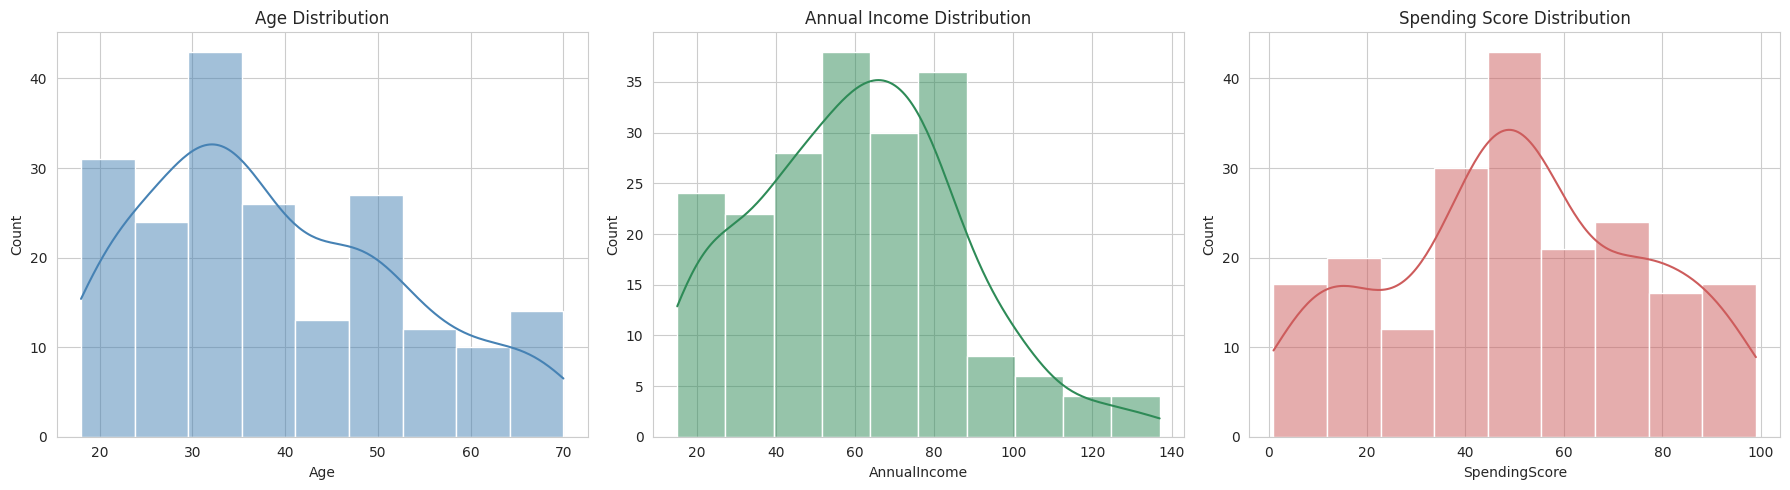

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["Age"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")

sns.histplot(df["AnnualIncome"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Annual Income Distribution")

sns.histplot(df["SpendingScore"], kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.show()


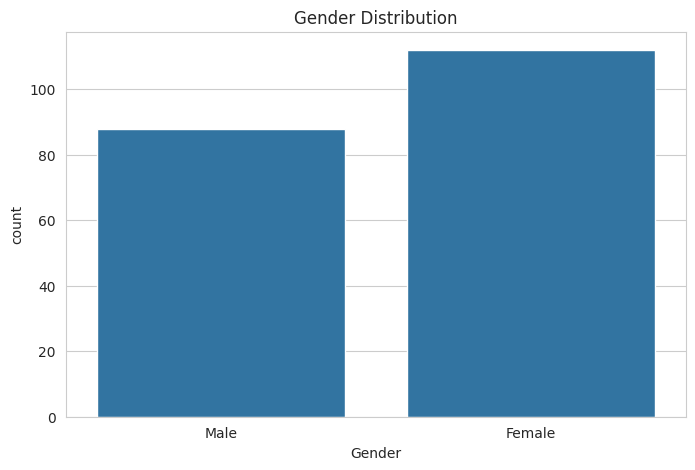

Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


In [33]:
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()

print(df["Gender"].value_counts(normalize=True) * 100)


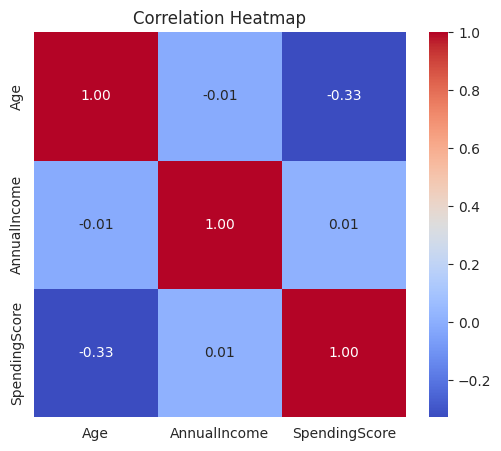

In [34]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=np.number).drop(columns=["CustomerID"])
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### Pairplot

Visualize the relationships between all numerical features, display the distribution of each feature on the diagonal, color data points by **Gender**, and exclude **CustomerID** since it is only an identifier.

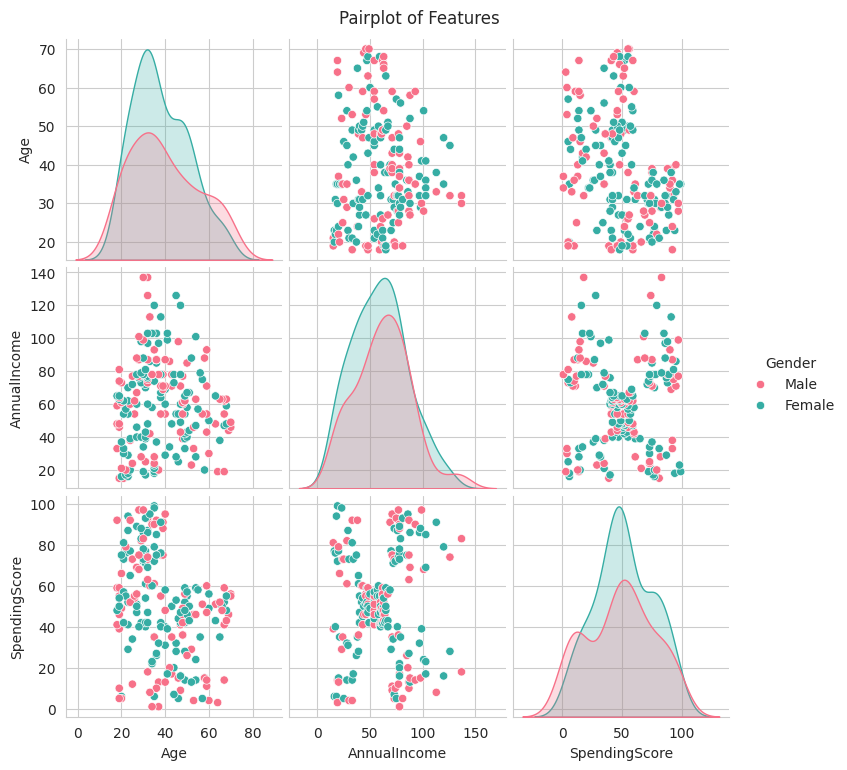

In [35]:
sns.pairplot(df.drop(columns=["CustomerID"]), hue="Gender", palette="husl")
plt.suptitle("Pairplot of Features", y=1.02)
plt.show()


## Step 3 — Preprocessing

We'll:
- Encode `Gender` (in case we want to use it later)
- Select features for clustering — start with `AnnualIncome` + `SpendingScore` (easy to visualize in 2D), then extend to include `Age`
- Scale features (important for distance-based algorithms like K-Means and DBSCAN)


In [36]:
# Encode the categorical 'Gender' column into numerical values
le = LabelEncoder()
df["Gender_encoded"] = le.fit_transform(df["Gender"])  # Female=0, Male=1 (order may vary)

# Select features for clustering
# 2D: Annual Income and Spending Score
# 3D: Age, Annual Income, and Spending Score
features_2d = ["AnnualIncome", "SpendingScore"]
features_3d = ["Age", "AnnualIncome", "SpendingScore"]

# Extract feature matrices
X_2d = df[features_2d].values
X_3d = df[features_3d].values

# Standardize the 2D feature set
# This ensures all features have the same scale
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Standardize the 3D feature set
scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

# Display the shape of the processed datasets
print("2D feature matrix shape:", X_2d_scaled.shape)
print("3D feature matrix shape:", X_3d_scaled.shape)


2D feature matrix shape: (200, 2)
3D feature matrix shape: (200, 3)


## Step 4 — Determine the Optimal Number of Clusters (K)

Evaluate different values of **K** using the **Elbow Method** and **Silhouette Score**. The Elbow Method measures within-cluster variation (inertia), while the Silhouette Score evaluates how well-separated the clusters are. The value of **K** with the highest Silhouette Score is selected as the optimal number of clusters for K-Means.


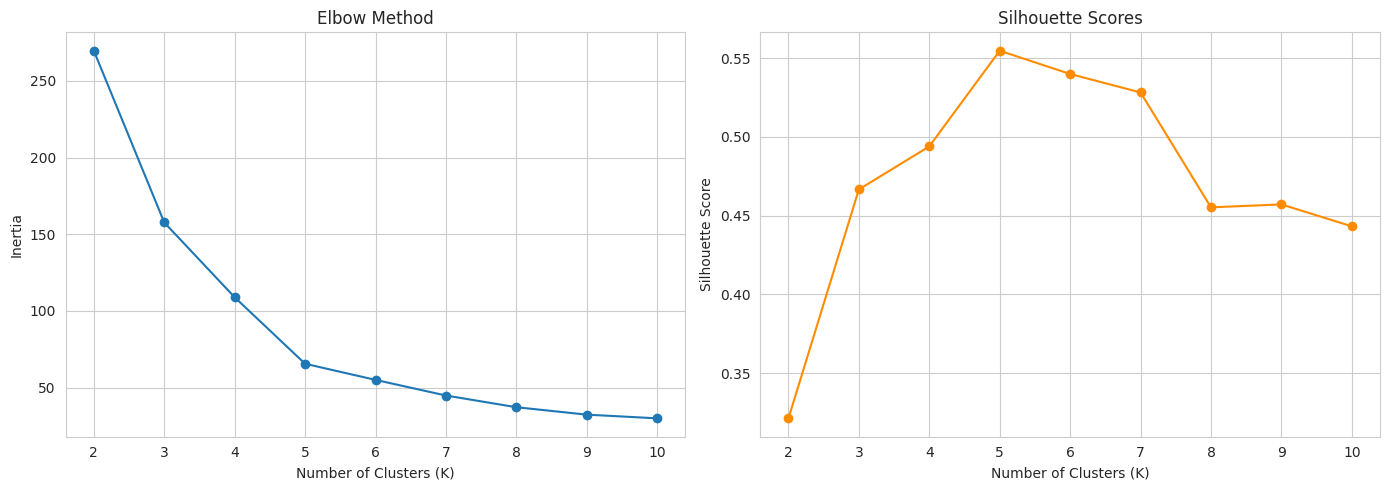

Best K by silhouette score: 5


In [37]:
# Evaluate different numbers of clusters using
# the Elbow Method and Silhouette Score
inertias = []
silhouette_scores = []
K_range = range(2, 11)

# Train K-Means models for different values of K
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_2d_scaled)

    # Store the within-cluster sum of squares (inertia)
    inertias.append(km.inertia_)

    # Store the silhouette score for cluster quality
    silhouette_scores.append(silhouette_score(X_2d_scaled, labels))

# Create side-by-side plots for model evaluation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method plot
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

# Silhouette Score plot
axes[1].plot(list(K_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# Select the optimal number of clusters
# based on the highest silhouette score
best_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"Best K by silhouette score: {best_k}")


## Step 5 — Apply K-Means (Final Model)

Train the final **K-Means** model using the selected optimal number of clusters (**K = 5**). Assign each customer to a cluster, examine the size of each cluster, and evaluate the clustering performance using the **Silhouette Score**.

In [38]:
# Set the final number of clusters
# (chosen based on the Elbow Method and Silhouette Score)
K_FINAL = 5

# Train the final K-Means clustering model
kmeans = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=10
)

# Assign each customer to a cluster
df["Cluster_KMeans"] = kmeans.fit_predict(X_2d_scaled)

# Display the number of samples in each cluster
print("Cluster sizes:")
print(df["Cluster_KMeans"].value_counts().sort_index())

# Evaluate the final clustering performance
# using the Silhouette Score
sil = silhouette_score(X_2d_scaled, df["Cluster_KMeans"])
print(f"\nSilhouette score for K={K_FINAL}: {sil:.3f}")


Cluster sizes:
Cluster_KMeans
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Silhouette score for K=5: 0.555


## Step 6 — Hierarchical Clustering (Comparison)

Apply **Hierarchical Clustering** using **Ward's linkage** method and visualize the clustering process with a **dendrogram**. The dendrogram helps identify a suitable number of clusters by showing how observations are merged based on their Euclidean distance.

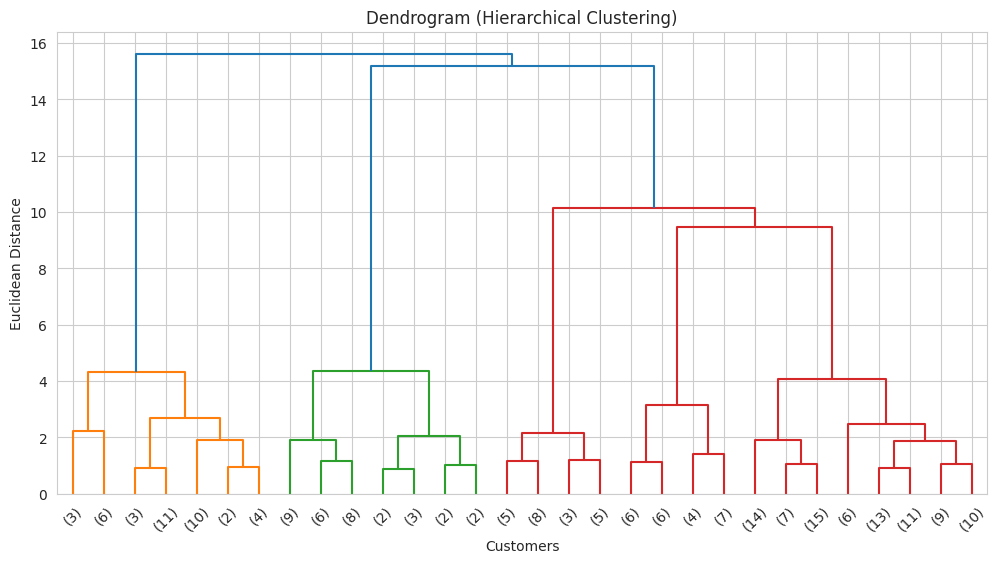

In [39]:
# Perform Hierarchical Clustering using Ward's linkage method
# Ward's method minimizes the variance within each cluster
linked = linkage(X_2d_scaled, method="ward")

# Plot the dendrogram to visualize the hierarchical clustering process
plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    truncate_mode="lastp",  # Display only the last merged clusters
    p=30                    # Show the final 30 cluster merges
)

# Customize the plot
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [40]:
# Create and train the Hierarchical (Agglomerative) Clustering model
# using Ward's linkage criterion
hierarchical = AgglomerativeClustering(
    n_clusters=K_FINAL,
    linkage="ward"
)

# Assign cluster labels to each customer
df["Cluster_Hierarchical"] = hierarchical.fit_predict(X_2d_scaled)

# Evaluate the clustering quality using the Silhouette Score
sil_hier = silhouette_score(
    X_2d_scaled,
    df["Cluster_Hierarchical"]
)

print(f"Silhouette score (Hierarchical, K={K_FINAL}): {sil_hier:.3f}")

Silhouette score (Hierarchical, K=5): 0.554


## Step 7 — DBSCAN (Comparison)

Train the **DBSCAN** clustering model to identify clusters based on data density without specifying the number of clusters in advance. The model also detects noise points (labeled **-1**) and reports the number of discovered clusters and outliers.

In [41]:
# Create and train the DBSCAN clustering model
# eps: maximum distance between neighboring points
# min_samples: minimum number of points required to form a dense region
dbscan = DBSCAN(eps=0.3, min_samples=5)

# Assign cluster labels to each customer
# Noise points are labeled as -1
df["Cluster_DBSCAN"] = dbscan.fit_predict(X_2d_scaled)

# Calculate the number of detected clusters
# (excluding noise points)
n_clusters_dbscan = len(set(df["Cluster_DBSCAN"])) - (
    1 if -1 in df["Cluster_DBSCAN"].values else 0
)

# Count the number of noise points
n_noise = (df["Cluster_DBSCAN"] == -1).sum()

# Display clustering results
print(f"DBSCAN found {n_clusters_dbscan} clusters and {n_noise} noise points")
print(df["Cluster_DBSCAN"].value_counts().sort_index())


DBSCAN found 7 clusters and 35 noise points
Cluster_DBSCAN
-1    35
 0    12
 1     5
 2     7
 3    88
 4    30
 5    14
 6     9
Name: count, dtype: int64


## Step 8 — Visualize the Clusters

### Visualize K-Means Clusters

Visualize the customer segments identified by the **K-Means** model using **Annual Income** and **Spending Score**. Display each cluster with a different color and mark the cluster **centroids** to highlight the center of each customer segment.

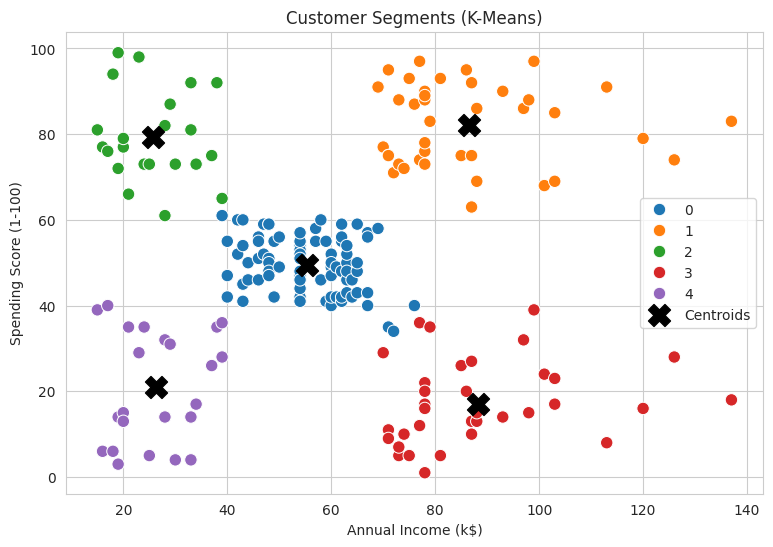

In [42]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x="AnnualIncome", y="SpendingScore",
    hue="Cluster_KMeans", palette="tab10", s=80
)

centroids = scaler_2d.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=250, label="Centroids")

plt.title("Customer Segments (K-Means)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()


### Compare Clustering Results

Visualize and compare the customer segments produced by **K-Means**, **Hierarchical Clustering**, and **DBSCAN**. Plot the clusters using **Annual Income** and **Spending Score** to compare how each algorithm partitions the data.

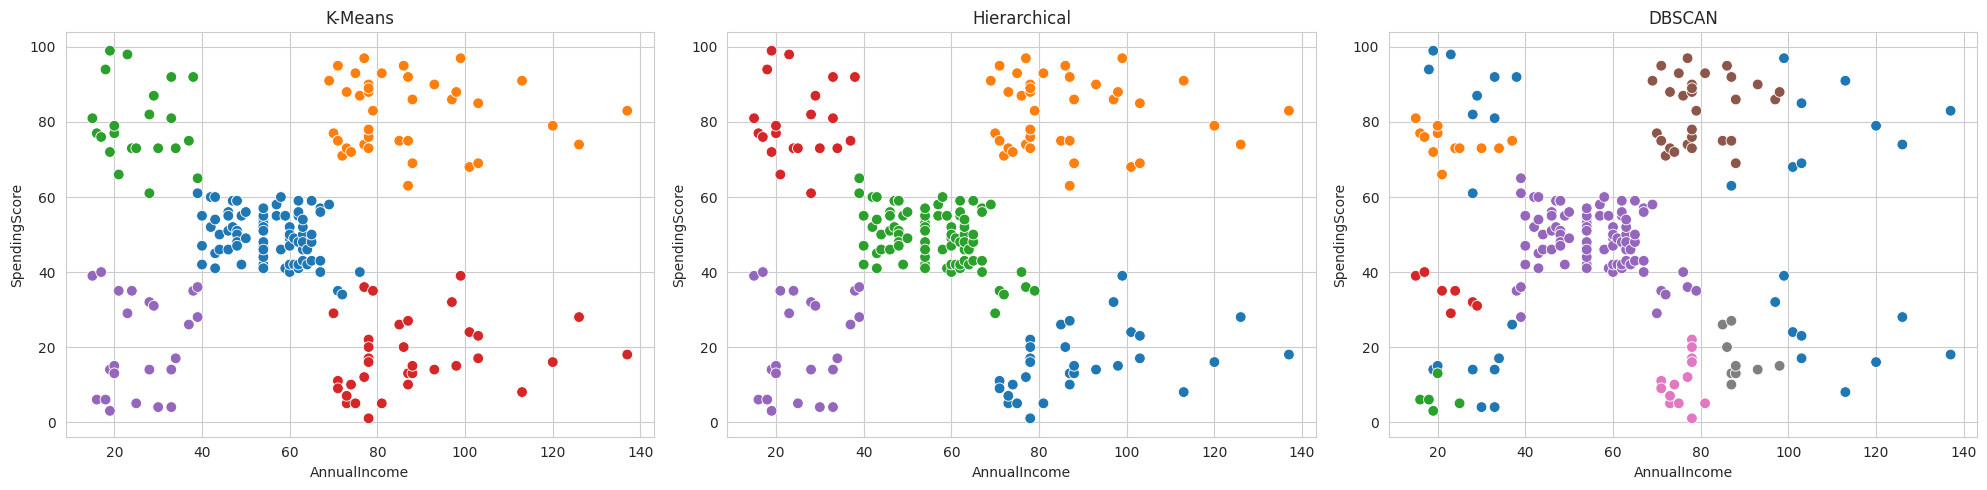

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, title in zip(
    axes,
    ["Cluster_KMeans", "Cluster_Hierarchical", "Cluster_DBSCAN"],
    ["K-Means", "Hierarchical", "DBSCAN"]
):
    sns.scatterplot(data=df, x="AnnualIncome", y="SpendingScore", hue=col, palette="tab10", s=60, ax=ax, legend=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()


### 3D Cluster Visualization

Visualize the **K-Means** customer segments in three dimensions using **Age**, **Annual Income**, and **Spending Score**. Color each point by its assigned cluster to better understand the separation of customer groups across all three features.

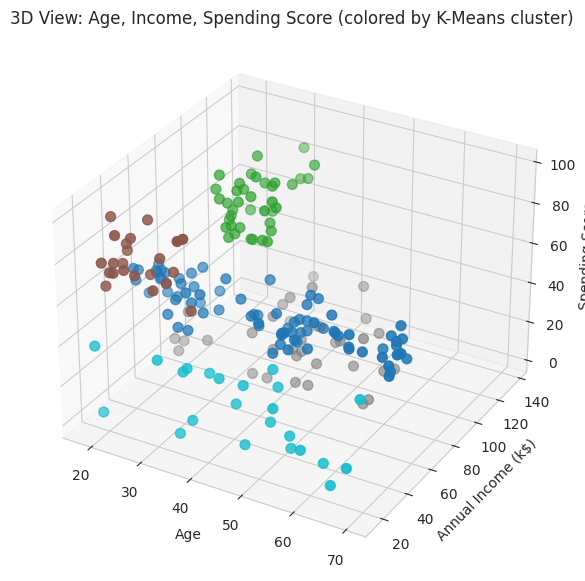

In [44]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["Age"], df["AnnualIncome"], df["SpendingScore"],
    c=df["Cluster_KMeans"], cmap="tab10", s=50
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score")
ax.set_title("3D View: Age, Income, Spending Score (colored by K-Means cluster)")
plt.show()


## Step 9 — Interpret & Profile the Clusters

Summarize each cluster's average characteristics and assign business-friendly labels.


In [45]:
cluster_profile = df.groupby("Cluster_KMeans")[["Age", "AnnualIncome", "SpendingScore"]].mean().round(1)
cluster_profile["Count"] = df["Cluster_KMeans"].value_counts().sort_index()
cluster_profile


,Age,AnnualIncome,SpendingScore,Count
Cluster_KMeans,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


Analyze the characteristics of each customer segment by calculating the average feature values for every cluster. Assign descriptive, business-friendly labels based on **Annual Income** and **Spending Score** to make the clusters easier to interpret and support marketing decisions.

In [46]:
# Example labeling logic — adjust based on your actual cluster_profile output
def label_cluster(row):
    if row["AnnualIncome"] > cluster_profile["AnnualIncome"].median() and row["SpendingScore"] > cluster_profile["SpendingScore"].median():
        return "High Income, High Spending (Target)"
    elif row["AnnualIncome"] > cluster_profile["AnnualIncome"].median() and row["SpendingScore"] <= cluster_profile["SpendingScore"].median():
        return "High Income, Low Spending (Careful)"
    elif row["AnnualIncome"] <= cluster_profile["AnnualIncome"].median() and row["SpendingScore"] > cluster_profile["SpendingScore"].median():
        return "Low Income, High Spending (Impulsive)"
    elif row["AnnualIncome"] <= cluster_profile["AnnualIncome"].median() and row["SpendingScore"] <= cluster_profile["SpendingScore"].median():
        return "Low Income, Low Spending (Budget-Conscious)"
    else:
        return "Average Income, Average Spending (Standard)"

cluster_profile["Label"] = cluster_profile.apply(label_cluster, axis=1)
cluster_profile


,Age,AnnualIncome,SpendingScore,Count,Label
Cluster_KMeans,,,,,
0,42.7,55.3,49.5,81,"Low Income, Low Spending (Budget-Conscious)"
1,32.7,86.5,82.1,39,"High Income, High Spending (Target)"
2,25.3,25.7,79.4,22,"Low Income, High Spending (Impulsive)"
3,41.1,88.2,17.1,35,"High Income, Low Spending (Careful)"
4,45.2,26.3,20.9,23,"Low Income, Low Spending (Budget-Conscious)"


In [47]:
# Save the final labeled dataset
#df.to_csv("Mall_Customers_Segmented.csv", index=False)
#print("Saved: Mall_Customers_Segmented.csv")
#df.head()